# Predicting Drug addiction

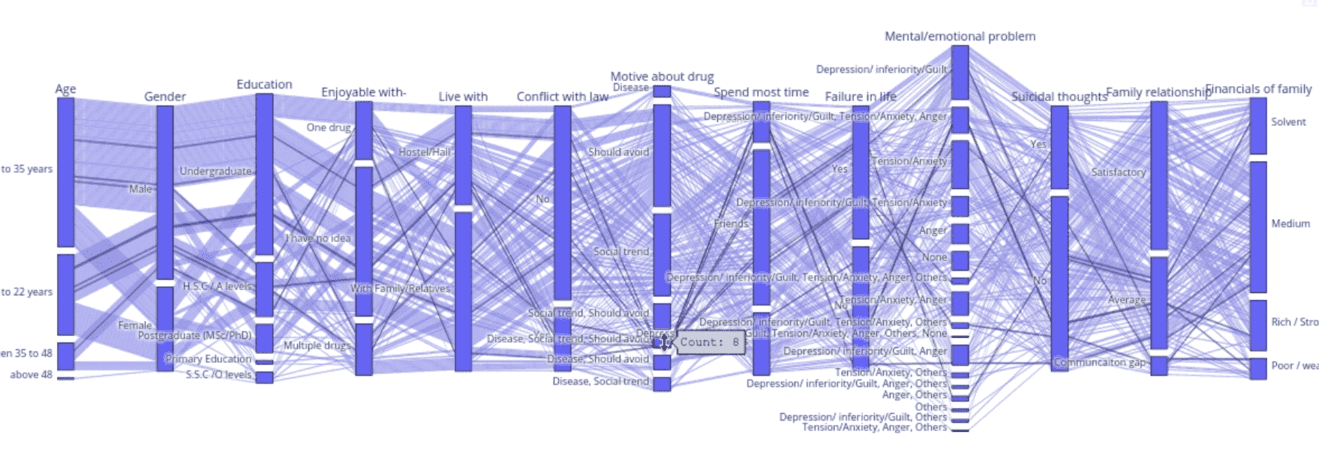

Drug addiction is a major global problem. 

Dataset used - https://www.kaggle.com/protikmostafa/drug-addiction-in-bangladesh-reasons

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('../input/drug-addiction-in-bangladesh-reasons/drugAddiction.csv')
df

In [ ]:
df.describe()

In [ ]:
df.info()

No missing value, hence we dont have to Drop Null or fill missing values

In [ ]:
plt.figure(figsize = (18 , 18))
for x in range(0,25):
        fig = plt.subplot(5 , 5 , x+1)
        sns.countplot(df[df.columns[x]])

In [ ]:
df['Mental/emotional problem'].unique()

In [ ]:
plt.figure(figsize = (12 , 12))
sns.countplot(df['Mental/emotional problem'])

In [ ]:
import plotly.express as px

fig = px.parallel_categories(df)

fig.show()

In [ ]:
df1 = df[df.columns[:13]]

fig = px.parallel_categories(df1)
fig.show()

# AutoGluon - AutoML package for tabular,computer vision, NLP tasks

In [ ]:
!python3 -m pip install autogluon

In [ ]:
from autogluon.tabular import TabularDataset , TabularPredictor

In [ ]:
from sklearn.model_selection import train_test_split

train_df , test_df = train_test_split(df , test_size = 0.2)

In [ ]:
predictor = TabularPredictor(path = './' , label = 'Frequency of drug usage').fit(train_df)

## Lets make prediction on test set

In [ ]:
predictor.evaluate(test_df)

In [ ]:
predictor.predict(test_df)

In [ ]:
predictor.predict_proba(test_df)

In [ ]:
predictor.leaderboard()